<div style="max-width:900px;margin:auto;padding:18px;border-radius:12px;background:#f7f9fc;border:1px solid #e1e8f0;font-family: 'Segoe UI', Roboto, 'Helvetica Neue', Arial, sans-serif;">
    <h1 style="margin:0 0 6px; font-size:28px; color:#0b63d6;">BioEMU: Scalable emulation of protein equilibrium ensembles</h1>
    <p style="margin:0 0 8px; color:#333;"><strong>A Demo:</strong> Downstream application of BioEMU</p>
    <p style="margin:6px 0;color:#555;"><strong>By:</strong> Aaryesh Deshpande: Originally meant for model demonstration session for CS8803MLG Course at Georgia Tech</p>
    <hr style="border:none;border-top:1px solid #e1e8f0;margin:10px 0;">
        <h3 style="margin:8px 0 6px;color:#0b63d6;">Ensemble-Based Druggable Pocket Finder</h3>
    <ul style="color:#333;line-height:1.6">
  BioEMU (conformations) → Ensemble pocket detection (persistent vs. cryptic) → Pocket graphs (residue nodes + physico-chem + geometry) → Attentive GNN (ranking).
    </ul>
    <h3>Introducion</h3>
    <img src="https://pockdrug.rpbs.univ-paris-diderot.fr/images/intro_3D.png" alt="drug-pocket" width=300></img><br>
    <p>This notebook showcases a downstream application of BioEMU, which generates multiple protein conformations representing equilibrium ensembles.
    Using these emulated structures, we perform graph-based analysis to detect and rank druggable pockets, structurally stable, solvent-accessible regions suitable for ligand binding.
    The workflow demonstrates how BioEMU enables dynamics-aware pocket discovery without costly molecular dynamics simulations.</p><br>
    <p style="color:#555;margin-top:8px;"><strong>Paper - 21:</strong> "Scalable emulation of protein equilibrium ensembles with generative deep learning"
    <a href="https://www.biorxiv.org/content/10.1101/2024.12.05.626885v1.full.pdf" target="_blank">Link</a></p>
</div>

In [ ]:
!pip install --upgrade pip
!pip3 install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu126
!pip install torch_geometric
!pip install networkx
!pip install numpy pandas matplotlib seaborn
!pip install scikit-learn scipy
!pip install biopython openmm rdkit py3Dmol MDAnalysis nglview

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 27.1 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
Looking in indexes: https://download.pytorch.org/whl/cu126
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 77.5 MB/s  0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.2/26.2 MB 178.4 MB/s  0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 150.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.0/14.0 MB 184.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.2/36.2 MB 90.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 148.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 115.0 MB/s  0:00:00
   ━━━━━━━

In [ ]:
!pip install bioemu

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 121.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.3/21.3 MB 142.8 MB/s  0:00:00
  DEPRECATION: Building 'fire' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'fire'. Discussion can be found at https://github.com/pypa/pip/issues/6334
  Created wheel for fire: filename=fire-0.7.0-py3-none-any.whl size=114249 sha256=5504cf921c494dc5e99466e00e206fa1b02b03e996455a7df9edf718346aa82e
  Stored in directory: /root/.cache/pip/wheels/9e/5b/45/29f72e55d87a29426b04b3cfdf20325c079eb97ab74f59017d
  DEPRECATION: Buil

In [ ]:
from google.colab import output

output.enable_custom_widget_manager()

Support for third party widgets will remain active for the duration of the session. To disable support:

In [ ]:
from google.colab import output

output.disable_custom_widget_manager()

## **Our Pipeline:**
1. Generate a few conformations using BioEMU
2. Detect pockets in each conformation
3. Build pocket graphs
4. GNN scoring for druggability

In [ ]:
import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.patches import Patch
import seaborn as sns
from pathlib import Path
from dataclasses import dataclass
import warnings

warnings.filterwarnings("ignore")

from bioemu.sample import main as bioemu_sample

from Bio.PDB import PDBParser, Selection
import MDAnalysis as mda
import nglview as nv
import networkx as nx
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GroupKFold
from scipy.spatial.distance import cdist, pdist
from sklearn.linear_model import LogisticRegression
from scipy.cluster.hierarchy import fcluster, linkage
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    f1_score,
    confusion_matrix,
)


import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import (
    GATConv,
    global_mean_pool,
    global_max_pool,
    global_add_pool,
    GraphNorm,
)
from torch_geometric.nn import MessagePassing
from torch.nn import Linear, Sequential, BatchNorm1d, Dropout, LayerNorm
from torch_geometric.data import Batch
from torch_geometric.loader import DataLoader

torch.__version__

'2.8.0+cu126'

In [ ]:
if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")


def set_seed(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
    print(f"{seed} seeds has been planted!")
    return seed


seed = set_seed(16)

16 seeds has been planted!


## **Part 1: Understanding the Problem**

**Static structures** (like AlphaFold predictions) show proteins in one conformation.

**Reality:** Proteins are dynamic! They sample many conformations and states. Traditionally we would compute the dynamic structures using a technique like Molecular Dynamics (MD)

**BioEmu:** Generates diverse conformational ensembles 10,000x faster than MD simulation.

Single structures miss transient/cryptic pockets. Ensembles capture conformational heterogeneity → richer pocket candidates.

#### **Protein Selection Setup**

This section defines a small set of benchmark proteins and selects one for BioEMU emulation.

* **`PROTEINS`** stores example protein sequences of varying lengths:

A few examples of protein used

  * *Chignolin* - 10 residues (small and fast to emulate)
  * *Villin* - 35 residues
  * *Protein G* - 56 residues

* **`NUM_SAMPLES`** specifies how many equilibrium conformations (BioEMU samples) to generate, here we go with 30, can change to more samples to get better results.



In [ ]:
# GLOBAL Properties
AA20 = [
    "ALA",
    "ARG",
    "ASN",
    "ASP",
    "CYS",
    "GLN",
    "GLU",
    "GLY",
    "HIS",
    "ILE",
    "LEU",
    "LYS",
    "MET",
    "PHE",
    "PRO",
    "SER",
    "THR",
    "TRP",
    "TYR",
    "VAL",
]
AA2IDX = {a: i for i, a in enumerate(AA20)}
HYDROPHOBICITY = {
    "ALA": 1.8,
    "CYS": 2.5,
    "ASP": -3.5,
    "GLU": -3.5,
    "PHE": 2.8,
    "GLY": -0.4,
    "HIS": -3.2,
    "ILE": 4.5,
    "LYS": -3.9,
    "LEU": 3.8,
    "MET": 1.9,
    "ASN": -3.5,
    "PRO": -1.6,
    "GLN": -3.5,
    "ARG": -4.5,
    "SER": -0.8,
    "THR": -0.7,
    "VAL": 4.2,
    "TRP": -0.9,
    "TYR": -1.3,
}
AROMATIC = {"PHE", "TRP", "TYR"}

In [ ]:
# Define protein sequences
PROTEINS = {
    "chignolin": "GYDPETGTWG",
    "villin": "MLSDEDFKAVFGMTRSAFANLPLWKQQNLKKEKGLF",
    "protein_g": "MQYKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGVDGEWTYDDATKTFTVTE",
    "trp_cage": "NLYIQWLKDGGPSSGRPPPS",
    "ww_domain": "IPGWEWECEDQIHWWEDG",
}

NUM_SAMPLES = 200  # 200 conformation states
SEED = seed
ROOT_OUT = Path("./bioemu_runs")

# Simple loop
for name, seq in PROTEINS.items():
    outdir = ROOT_OUT / f"{name}_n{NUM_SAMPLES}_s{SEED}"
    outdir.mkdir(parents=True, exist_ok=True)

    print(f"\nRunning BioEMU for {name} ({len(seq)} aa)")
    bioemu_sample(sequence=seq, num_samples=NUM_SAMPLES, output_dir=str(outdir))
    print(f"Done -> {outdir}")


Running BioEMU for chignolin (10 aa)


checkpoints/bioemu-v1.1/checkpoint.ckpt:   0%|          | 0.00/125M [00:00<?, ?B/s]

config.yaml:   0%|          | 0.00/580 [00:00<?, ?B/s]

Sampling batches...:   0%|          | 0/1 [00:00<?, ?it/s]INFO:bioemu.get_embeds:Colabfold not present under /root/.bioemu_colabfold. Installing...
INFO:bioemu.get_embeds:Install log saved in /root/.bioemu_colabfold/install_log.txt.
Sampling batches...: 100%|██████████| 1/1 [15:20<00:00, 920.78s/it]


✓ Done -> bioemu_runs/chignolin_n200_sNone

Running BioEMU for villin (36 aa)


Sampling batches...: 100%|██████████| 3/3 [01:34<00:00, 31.43s/it]


✓ Done -> bioemu_runs/villin_n200_sNone

Running BioEMU for protein_g (56 aa)


Sampling batches...: 100%|██████████| 7/7 [02:25<00:00, 20.86s/it]


✓ Done -> bioemu_runs/protein_g_n200_sNone

Running BioEMU for trp_cage (20 aa)


Sampling batches...: 100%|██████████| 1/1 [00:51<00:00, 51.54s/it]


✓ Done -> bioemu_runs/trp_cage_n200_sNone

Running BioEMU for ww_domain (18 aa)


Sampling batches...: 100%|██████████| 1/1 [00:49<00:00, 49.88s/it]


✓ Done -> bioemu_runs/ww_domain_n200_sNone


## **Part 2: Ensemble Pocket Detection from Real Structures**

This module implements an **ensemble-based pocket detection** approach using **MDAnalysis** on real protein structures and trajectories.

**Overview**

`EnsemblePocketFinder` identifies **transient and persistent pockets** across molecular dynamics simulations by clustering residues based on **spatial proximity, local density, and burial depth**.
It adapts parameters for different protein sizes and prevents over-clustering of the entire structure.

**Key Steps**

1. **Setup:** Loads topology (`.pdb`) and trajectory (`.xtc`) and extracts Cα coordinates.
2. **Candidate Selection:** Finds residues within distance cutoffs and computes depth from the molecular center.
3. **Clustering:** Groups residues into pockets using **hierarchical** or **DBSCAN** clustering (depending on protein size).
4. **Characterization:** Calculates pocket size, hydrophobicity, aromaticity, and depth.
5. **Cryptic Detection:** Uses spatial recurrence across frames to classify pockets as **persistent** or **cryptic**.

**Outputs**

* **`pocket_data`**: Annotated pocket information per frame.
* **`pockets_per_conf`**: Number of detected pockets per conformation.
* **Plots**: Pocket frequency, size distribution, and persistent vs. cryptic classification.


In [ ]:
@dataclass
class EnsemblePocketFinder:
    top_path: str
    xtc_path: str
    min_residues: int = 3
    distance_cutoff: float | None = 8.0  # if None → adaptive per frame
    bin_step: float = 0.5  # angstrom for cryptic binning
    cryptic_frac: float = 0.30  # < 30% of frames → cryptic
    max_pocket_fraction: float = 0.6  # max fraction of protein that can be a pocket

    # Core Setup
    def _setup(self):
        self.u = mda.Universe(self.top_path, self.xtc_path)
        self.ca = self.u.select_atoms("protein and name CA")
        # residue metadata aligned with CA
        self.resnames = np.array([r.resname for r in self.ca.residues])
        self.resids = np.array([r.resid for r in self.ca.residues])
        self.n_frames = len(self.u.trajectory)

    def _cluster(
        self, coords: np.ndarray, candidates: list[dict], rg: float
    ) -> list[dict]:
        if len(candidates) < self.min_residues:
            return []

        X = np.array([c["coord"] for c in candidates], dtype=float)

        # Edge Case: Prevent whole protein from being a single pocket
        max_pocket_size = int(len(self.ca) * self.max_pocket_fraction)

        # For very small proteins less than 20aa
        if len(self.ca) < 20:
            # DBSCAN for finding surface pockets
            from sklearn.cluster import DBSCAN

            eps_value = 4.0 if len(self.ca) <= 10 else 5.0
            clustering = DBSCAN(eps=eps_value, min_samples=2).fit(X)
            labels = clustering.labels_
        else:
            # Hierarchical clustering for larger proteins
            Z = linkage(X, method="ward")
            t = max(6.0, 1.5 * rg)  # Increased threshold
            labels = fcluster(Z, t=t, criterion="distance")

        pockets = []
        unique_labels = np.unique(labels)
        for cid in unique_labels:
            if cid == -1:  # Skip noise points in DBSCAN
                continue
            grp = [candidates[i] for i in range(len(candidates)) if labels[i] == cid]

            # Skip if pocket is too large likely the whole protein
            if len(grp) > max_pocket_size:
                # Trying to split large clusters for small proteins
                if len(self.ca) <= 20:
                    grp_coords = np.array([g["coord"] for g in grp])
                    from sklearn.cluster import KMeans

                    n_subclusters = max(2, len(grp) // 5)
                    kmeans = KMeans(
                        n_clusters=n_subclusters, random_state=16, n_init=10
                    )
                    sub_labels = kmeans.fit_predict(grp_coords)

                    for sub_id in range(n_subclusters):
                        sub_grp = [
                            grp[i] for i in range(len(grp)) if sub_labels[i] == sub_id
                        ]
                        if self.min_residues <= len(sub_grp) <= max_pocket_size:
                            pockets.append(
                                {
                                    "residues": sub_grp,
                                    "size": len(sub_grp),
                                    "center": np.mean(
                                        [g["coord"] for g in sub_grp], axis=0
                                    ),
                                }
                            )
                continue

            if len(grp) >= self.min_residues:
                pockets.append(
                    {
                        "residues": grp,
                        "size": len(grp),
                        "center": np.mean([g["coord"] for g in grp], axis=0),
                    }
                )

        # For very small proteins, limit number of pockets per frame
        if len(self.ca) <= 15:
            pockets = pockets[:2]  # Max 2 pockets for tiny proteins
        elif len(self.ca) <= 30:
            pockets = pockets[:3]  # Max 3 pockets for small proteins

        return pockets

    def _detect_pockets_from_coords(self, coords: np.ndarray) -> list[dict]:
        n = coords.shape[0]
        if n < self.min_residues:
            return []

        center = coords.mean(axis=0)
        dmat = cdist(coords, coords)

        # Adaptive parameters for small proteins
        rg = float(np.sqrt(((coords - center) ** 2).sum() / n + 1e-9))

        # For very small proteins less than 10aa
        if n <= 10:
            # Find local clusters instead of whole protein
            from scipy.spatial import ConvexHull

            try:
                hull = ConvexHull(coords)
                hull_points = set(hull.vertices)
                non_hull = [i for i in range(n) if i not in hull_points]

                if len(non_hull) >= 2:
                    # Focus on buried residues
                    cand = []
                    for i in non_hull:
                        neighbors = np.sum(dmat[i] < 5.0) - 1
                        cand.append(
                            {
                                "residue_id": int(self.resids[i]),
                                "residue_name": str(self.resnames[i]),
                                "coord": coords[i],
                                "neighbors": neighbors,
                                "depth": float(np.linalg.norm(coords[i] - center)),
                            }
                        )
                    # Add nearby surface residues
                    for i in hull_points:
                        min_dist_to_buried = min(
                            [dmat[i, j] for j in non_hull], default=100
                        )
                        if min_dist_to_buried < 5.0:
                            cand.append(
                                {
                                    "residue_id": int(self.resids[i]),
                                    "residue_name": str(self.resnames[i]),
                                    "coord": coords[i],
                                    "neighbors": np.sum(dmat[i] < 5.0) - 1,
                                    "depth": float(np.linalg.norm(coords[i] - center)),
                                }
                            )
                    if len(cand) >= self.min_residues:
                        return self._cluster(coords, cand, rg)
            except:
                pass

            # Fallback: find densest regions
            densities = [np.sum(dmat[i] < 5.0) for i in range(n)]
            dense_idx = np.argsort(densities)[-6:]  # Top 6 densest
            cand = []
            for i in dense_idx:
                cand.append(
                    {
                        "residue_id": int(self.resids[i]),
                        "residue_name": str(self.resnames[i]),
                        "coord": coords[i],
                        "neighbors": densities[i] - 1,
                        "depth": float(np.linalg.norm(coords[i] - center)),
                    }
                )
            return self._cluster(coords, cand, rg)

        elif n <= 20:  # Very small proteins
            cutoff = self.distance_cutoff
            neigh_lo = 1
            neigh_hi = min(8, n - 2)  # NEW: Cap at 8 neighbors
            depth_lo = 0.0
            depth_hi = 3.0 * rg
        elif n <= 40:  # Small proteins
            cutoff = max(6.0, self.distance_cutoff)
            neigh_lo = 2
            neigh_hi = max(neigh_lo + 1, min(12, int(0.6 * n)))  # NEW: Cap
            depth_lo = 0.1 * rg
            depth_hi = 2.8 * rg
        else:  # Medium proteins
            cutoff = self.distance_cutoff or max(5.0, 0.8 * max(rg, 8.0))
            neigh_lo = max(2, int(0.1 * n))
            neigh_hi = max(neigh_lo + 1, int(0.7 * n))
            depth_lo = 0.2 * rg
            depth_hi = 2.5 * rg

        # Find pocket candidates
        cand = []
        for i in range(n):
            neighbors = int((dmat[i] < cutoff).sum() - 1)
            depth = float(np.linalg.norm(coords[i] - center))

            # Include residue if it meets relaxed criteria
            if neighbors >= neigh_lo and neighbors <= neigh_hi:
                if depth_lo <= depth <= depth_hi:
                    cand.append(
                        {
                            "residue_id": int(self.resids[i]),
                            "residue_name": str(self.resnames[i]),
                            "coord": coords[i],
                            "neighbors": neighbors,
                            "depth": depth,
                        }
                    )

        # For very small proteins, also consider surface patches
        if n <= 20 and len(cand) < n * 0.3:
            # Add surface residues with good connectivity
            for i in range(n):
                already_added = any(c["residue_id"] == self.resids[i] for c in cand)
                if not already_added:
                    neighbors = int((dmat[i] < cutoff).sum() - 1)
                    if neighbors >= 2:  # At least 2 neighbors
                        cand.append(
                            {
                                "residue_id": int(self.resids[i]),
                                "residue_name": str(self.resnames[i]),
                                "coord": coords[i],
                                "neighbors": neighbors,
                                "depth": float(np.linalg.norm(coords[i] - center)),
                            }
                        )

        if len(cand) < self.min_residues:
            return []

        return self._cluster(coords, cand, rg)

    def run(self, max_frames: int | None = None) -> tuple[list[dict], list[int]]:
        """Runner: Process frames -> (pocket_data, pockets_per_conf)."""
        self._setup()
        limit = min(max_frames or self.n_frames, self.n_frames)

        pocket_data, pockets_per_conf = [], []

        print(f"Processing {limit} frames for protein with {len(self.ca)} residues...")

        for fi, ts in enumerate(self.u.trajectory[:limit]):
            coords = self.ca.positions.copy()
            pockets = self._detect_pockets_from_coords(coords)
            pockets_per_conf.append(len(pockets))

            for pk in pockets:
                hydros = []
                arom = 0
                for r in pk["residues"]:
                    rn = r["residue_name"]
                    hydros.append(HYDROPHOBICITY.get(rn, 0.0))
                    if rn in AROMATIC:
                        arom += 1
                avg_h = float(np.mean(hydros)) if hydros else 0.0

                pocket_data.append(
                    {
                        "conf_id": fi,
                        "size": pk["size"],
                        "hydrophobicity": avg_h / 5.0,
                        "has_aromatic": 1 if arom > 0 else 0,
                        "depth": float(np.mean([r["depth"] for r in pk["residues"]])),
                        "volume": pk["size"] * 30.0,
                        "center": pk["center"],
                        "residues": pk["residues"],
                    }
                )

            if (fi + 1) % 50 == 0:
                print(
                    f"  Processed {fi + 1}/{limit} frames, found {len(pocket_data)} pockets so far"
                )

        print(f"Total pockets found: {len(pocket_data)}")
        if pocket_data:
            print(
                f"Pocket size range: {min([p['size'] for p in pocket_data])} - "
                f"{max([p['size'] for p in pocket_data])} residues"
            )

        return pocket_data, pockets_per_conf

    def mark_cryptic(self, pocket_data: list[dict], n_frames_used: int) -> None:
        if not pocket_data:
            return

        # For small proteins, use larger bins
        if len(self.ca) <= 30:
            bin_step = 3.0  # Much larger bins for small proteins
            thresh_fraction = 0.15  # Only need 15% occurrence for persistence
        else:
            bin_step = self.bin_step
            thresh_fraction = self.cryptic_frac

        def bin_key(x, step=bin_step):
            return tuple((np.asarray(x) / step).round().astype(int))

        # Count spatial bins
        counts = {}
        for p in pocket_data:
            k = bin_key(p["center"])
            counts[k] = counts.get(k, 0) + 1

        thresh = thresh_fraction * n_frames_used

        # check for similar pockets across frames
        # Group pockets by size first
        size_groups = {}
        for i, p in enumerate(pocket_data):
            size = p["size"]
            if size not in size_groups:
                size_groups[size] = []
            size_groups[size].append((i, p))

        # Mark persistent pockets
        persistent_indices = set()

        for size, group in size_groups.items():
            if len(group) >= thresh:
                # Check spatial clustering within this size group
                centers = np.array([p["center"] for _, p in group])

                # Use DBSCAN to find persistent spatial clusters
                from sklearn.cluster import DBSCAN

                clustering = DBSCAN(eps=5.0, min_samples=int(thresh / 2)).fit(centers)

                for cluster_id in set(clustering.labels_):
                    if cluster_id != -1:  # Not noise
                        cluster_members = [
                            group[i][0]
                            for i in range(len(group))
                            if clustering.labels_[i] == cluster_id
                        ]
                        if len(cluster_members) >= thresh:
                            persistent_indices.update(cluster_members)

        # Mark cryptic vs persistent
        for i, p in enumerate(pocket_data):
            k = bin_key(p["center"])

            is_persistent = (counts[k] >= thresh) or (i in persistent_indices)
            p["is_cryptic"] = not is_persistent

        if all(p["is_cryptic"] for p in pocket_data):
            sorted_counts = sorted(counts.items(), key=lambda x: x[1], reverse=True)
            top_locations = set([k for k, count in sorted_counts[:3]])

            for p in pocket_data:
                if bin_key(p["center"]) in top_locations:
                    p["is_cryptic"] = False

        n_cryptic = sum(p["is_cryptic"] for p in pocket_data)
        n_persistent = len(pocket_data) - n_cryptic
        print(
            f"Persistent pockets: {n_persistent} ({100 * n_persistent / len(pocket_data):.1f}%)"
        )
        print(
            f"Cryptic pockets: {n_cryptic} ({100 * n_cryptic / len(pocket_data):.1f}%)"
        )


Detecting pockets for chignolin
Processing 190 frames for protein with 10 residues...
  Processed 50/190 frames, found 50 pockets so far
  Processed 100/190 frames, found 101 pockets so far
  Processed 150/190 frames, found 150 pockets so far
Total pockets found: 192
Pocket size range: 3 - 6 residues
Persistent pockets: 176 (91.7%)
Cryptic pockets: 16 (8.3%)
Total pockets: 192
Cryptic pockets: 16
Avg pockets/frame: 1.01


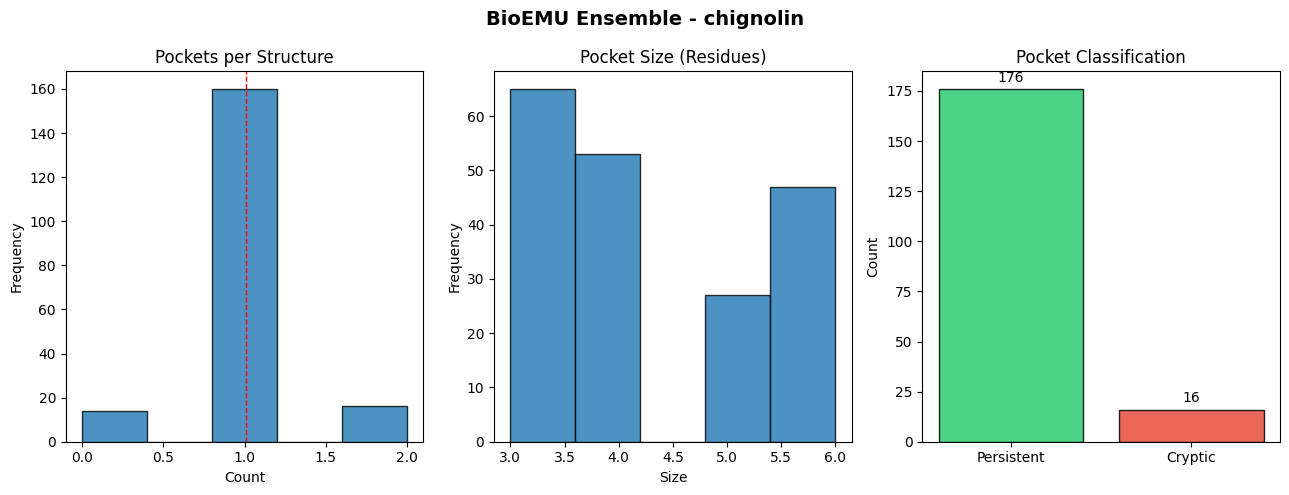


Detecting pockets for protein_g
Processing 193 frames for protein with 56 residues...
  Processed 50/193 frames, found 259 pockets so far
  Processed 100/193 frames, found 526 pockets so far
  Processed 150/193 frames, found 781 pockets so far
Total pockets found: 991
Pocket size range: 3 - 12 residues
Persistent pockets: 473 (47.7%)
Cryptic pockets: 518 (52.3%)
Total pockets: 991
Cryptic pockets: 518
Avg pockets/frame: 5.13


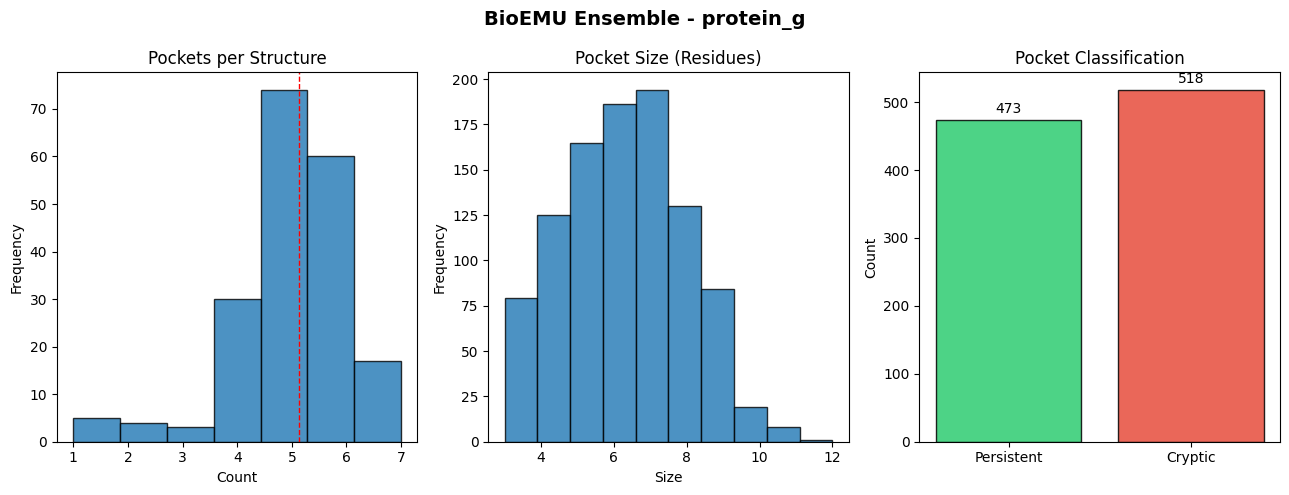


Detecting pockets for trp_cage
Processing 184 frames for protein with 20 residues...
  Processed 50/184 frames, found 150 pockets so far
  Processed 100/184 frames, found 300 pockets so far
  Processed 150/184 frames, found 450 pockets so far
Total pockets found: 552
Pocket size range: 3 - 10 residues
Persistent pockets: 376 (68.1%)
Cryptic pockets: 176 (31.9%)
Total pockets: 552
Cryptic pockets: 176
Avg pockets/frame: 3.00


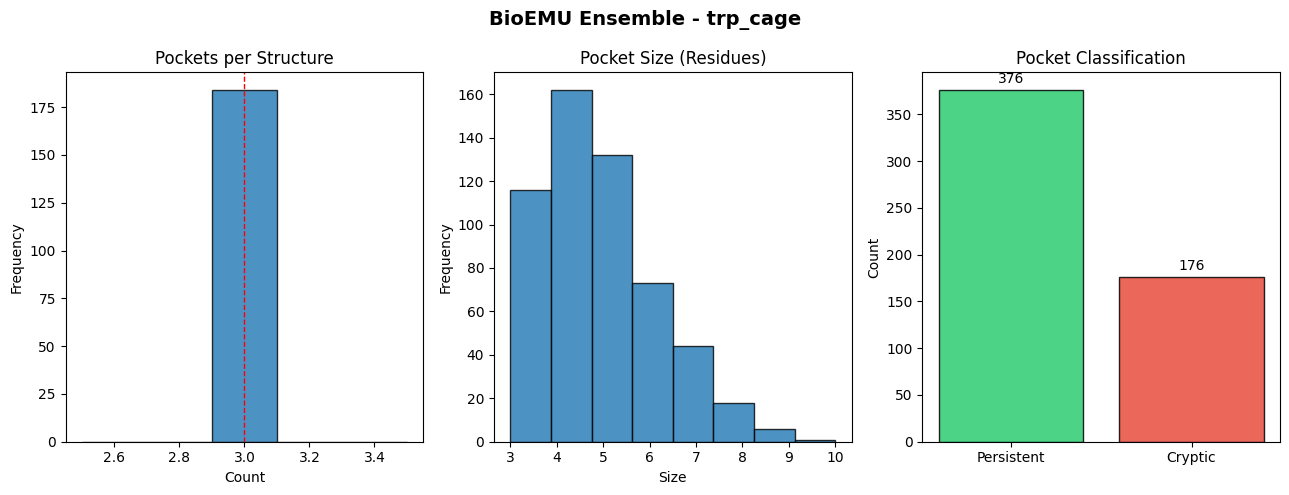


Detecting pockets for villin
Processing 198 frames for protein with 36 residues...
  Processed 50/198 frames, found 273 pockets so far
  Processed 100/198 frames, found 550 pockets so far
  Processed 150/198 frames, found 821 pockets so far
Total pockets found: 1077
Pocket size range: 3 - 14 residues
Persistent pockets: 384 (35.7%)
Cryptic pockets: 693 (64.3%)
Total pockets: 1077
Cryptic pockets: 693
Avg pockets/frame: 5.44


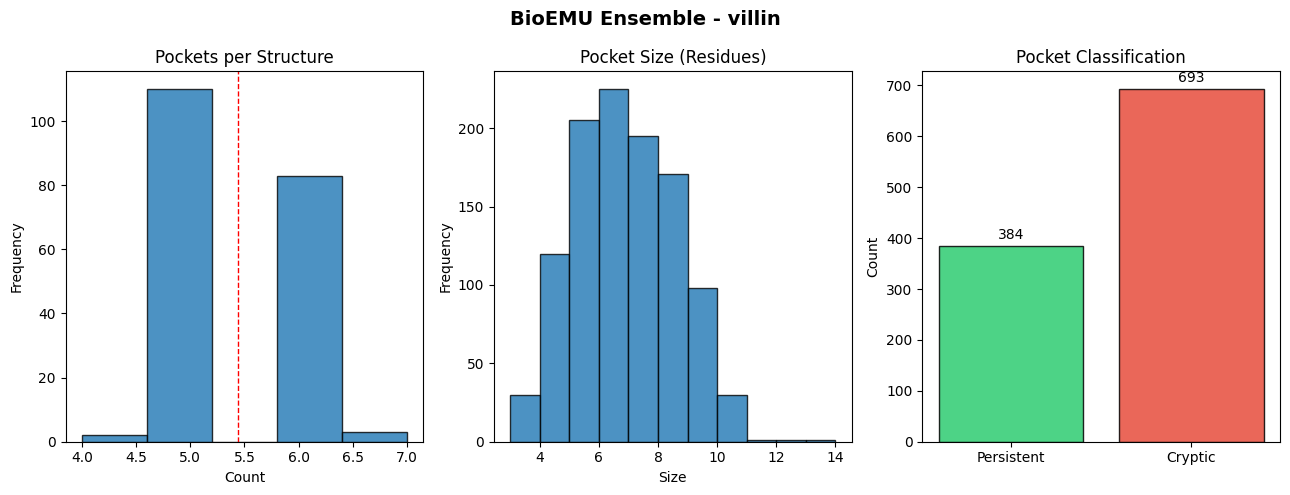


Detecting pockets for ww_domain
Processing 185 frames for protein with 18 residues...
  Processed 50/185 frames, found 149 pockets so far
  Processed 100/185 frames, found 299 pockets so far
  Processed 150/185 frames, found 449 pockets so far
Total pockets found: 553
Pocket size range: 3 - 10 residues
Persistent pockets: 499 (90.2%)
Cryptic pockets: 54 (9.8%)
Total pockets: 553
Cryptic pockets: 54
Avg pockets/frame: 2.99


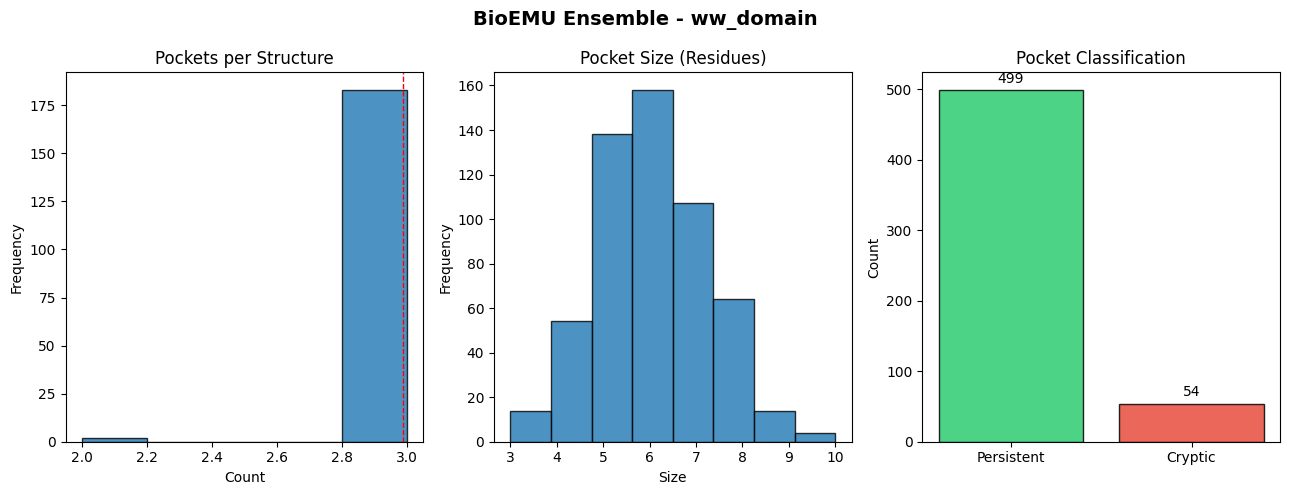

In [ ]:
ROOT_DIR = Path("./bioemu_runs")
ALL_RUNS = sorted(ROOT_DIR.glob("*_n*_s*"))

results_summary = []

for run_dir in ALL_RUNS:
    name = run_dir.name.split("_n")[0]
    top_path = run_dir / "topology.pdb"
    xtc_path = run_dir / "samples.xtc"

    if not (top_path.exists() and xtc_path.exists()):
        print(f"Missing topology/xtc files.")
        continue

    print(f"\nDetecting pockets for {name}")
    finder = EnsemblePocketFinder(
        top_path=str(top_path),
        xtc_path=str(xtc_path),
        min_residues=3,
        distance_cutoff=6.0,
    )

    pocket_data, pockets_per_conf = finder.run(max_frames=NUM_SAMPLES)
    finder.mark_cryptic(pocket_data, n_frames_used=min(NUM_SAMPLES, finder.n_frames))

    total_pockets = len(pocket_data)
    cryptic = sum(1 for p in pocket_data if p["is_cryptic"])
    avg_pockets = np.mean(pockets_per_conf) if pockets_per_conf else 0.0

    results_summary.append(
        {
            "protein": name,
            "frames": finder.n_frames,
            "pockets": total_pockets,
            "cryptic": cryptic,
            "avg_pockets_per_frame": round(avg_pockets, 2),
        }
    )

    print(f"Total pockets: {total_pockets}")
    print(f"Cryptic pockets: {cryptic}")
    print(f"Avg pockets/frame: {avg_pockets:.2f}")

    total_pockets = len(pocket_data)
    cryptic_count = sum(p["is_cryptic"] for p in pocket_data)
    persistent_count = total_pockets - cryptic_count
    sizes = [p["size"] for p in pocket_data]

    fig, axes = plt.subplots(1, 3, figsize=(13, 5))
    fig.suptitle(f"BioEMU Ensemble - {name}", fontsize=14, fontweight="bold")

    # Pockets per conformation
    axes[0].hist(
        pockets_per_conf,
        bins=max(5, len(set(pockets_per_conf))),
        alpha=0.8,
        edgecolor="black",
    )
    axes[0].axvline(np.mean(pockets_per_conf), color="red", linestyle="--", linewidth=1)
    axes[0].set_title("Pockets per Structure", fontsize=12)
    axes[0].set_xlabel("Count")
    axes[0].set_ylabel("Frequency")

    # Pocket size distribution
    axes[1].hist(
        sizes, bins=min(12, max(5, len(set(sizes)))), alpha=0.8, edgecolor="black"
    )
    axes[1].set_title("Pocket Size (Residues)", fontsize=12)
    axes[1].set_xlabel("Size")
    axes[1].set_ylabel("Frequency")

    # Persistent vs Cryptic
    axes[2].bar(
        ["Persistent", "Cryptic"],
        [persistent_count, cryptic_count],
        alpha=0.85,
        edgecolor="black",
        color=["#2ecc71", "#e74c3c"],
    )
    axes[2].bar_label(axes[2].containers[0], padding=3, fontsize=10)
    axes[2].set_title("Pocket Classification", fontsize=12)
    axes[2].set_ylabel("Count")

    plt.tight_layout()
    plt.show()

## **Part 3: Pocket Graph Construction**

This section converts detected **pockets** into structured **graphs** for downstream GNN modeling. Each graph encodes **residues as nodes**, **contacts as edges**, and integrates **geometric, physicochemical, and persistence features**.

**Overview**
* Builds **node**, **edge**, and **global** features from pocket data.
* Captures spatial, hydrophobic, electrostatic, and structural information.
* Generates a **druggability target score** ∈ [0, 1] based on pocket stability and composition.

**Feature Summary**
* **Node:** one-hot amino acid type, hydrophobicity, aromaticity, polarity, charge, depth, neighbor count, distance to pocket center.
* **Edge:** contact distance kernel, hydrophobic/electrostatic/aromatic interactions.
* **Global:** pocket size, volume, compactness, charge density, flexibility, mean hydrophobicity, aromatic content.

**Outputs**
Each pocket → PyTorch Geometric `Data` object with:

* `x` : node features `edge_index`, `edge_attr`
* `u` : global features `y`: druggability target
* `pos` : residue coordinates

Visualizations show 3D pocket graphs, 2D connectivity, and feature distributions.


In [ ]:
def one_hot_aa(resname):
    v = np.zeros(len(AA20), dtype=np.float32)
    if resname in AA2IDX:
        v[AA2IDX[resname]] = 1.0
    return v


def radius_graph(coords, cutoff=8.0):
    # returns undirected COO edge_index
    n = coords.shape[0]
    d2 = np.sum((coords[:, None, :] - coords[None, :, :]) ** 2, axis=-1)
    E = np.argwhere((d2 < cutoff**2) & (d2 > 1e-8))
    # make symmetric (COO)
    e = np.concatenate([E, E[:, [1, 0]]], axis=0)
    return torch.tensor(e.T, dtype=torch.long)


def z(x):
    x = np.asarray(x, dtype=np.float32)
    s = np.std(x) + 1e-8
    return (x - np.mean(x)) / s


def build_persistence_map(pocket_data, bin_step=0.5):
    def key3(x):
        return tuple((np.array(x) / bin_step).round().astype(int))

    counts = {}
    for p in pocket_data:
        k = key3(p["center"])
        counts[k] = counts.get(k, 0) + 1
    return counts, key3

In [ ]:
class PocketGraphBuilder:
    def __init__(self, pocket_data, persistence_cutoff=0.3):
        self.pocket_data = pocket_data
        self.persistence_cutoff = persistence_cutoff
        self.scaler = StandardScaler()

    def compute_advanced_features(self, pocket):
        residues = pocket["residues"]
        coords = np.array([r["coord"] for r in residues])

        # Geometric features
        centroid = coords.mean(axis=0)
        distances_to_centroid = np.linalg.norm(coords - centroid, axis=1)

        # Compute convex hull volume estimate
        if len(coords) >= 4:
            from scipy.spatial import ConvexHull

            try:
                hull = ConvexHull(coords)
                convex_volume = hull.volume
                surface_area = hull.area
            except:
                convex_volume = pocket["volume"]
                surface_area = pocket["size"] * 10.0
        else:
            convex_volume = pocket["volume"]
            surface_area = pocket["size"] * 10.0

        # Compactness metric
        compactness = convex_volume / (surface_area + 1e-6)

        # Electrostatic features
        charged_res = {"ARG", "LYS", "ASP", "GLU", "HIS"}
        charge_count = sum(1 for r in residues if r["residue_name"] in charged_res)
        charge_density = charge_count / (pocket["size"] + 1e-6)

        # Secondary structure propensity
        helix_formers = {"ALA", "GLU", "LEU", "MET"}
        sheet_formers = {"VAL", "ILE", "TYR", "TRP", "PHE"}
        helix_prop = (
            sum(1 for r in residues if r["residue_name"] in helix_formers)
            / pocket["size"]
        )
        sheet_prop = (
            sum(1 for r in residues if r["residue_name"] in sheet_formers)
            / pocket["size"]
        )

        # Flexibility score (based on B-factors proxy)
        flexibility = np.std(distances_to_centroid) / (
            np.mean(distances_to_centroid) + 1e-6
        )

        return {
            "convex_volume": convex_volume,
            "surface_area": surface_area,
            "compactness": compactness,
            "charge_density": charge_density,
            "helix_propensity": helix_prop,
            "sheet_propensity": sheet_prop,
            "flexibility": flexibility,
            "std_depth": np.std([r["depth"] for r in residues]),
        }

    def create_node_features(self, residue, pocket_stats):
        # Original features
        resname = residue["residue_name"]
        coord = residue["coord"]
        depth = residue["depth"]
        neighbors = residue["neighbors"]

        # Amino acid properties
        aa_props = {
            "hydrophobicity": HYDROPHOBICITY.get(resname, 0.0) / 5.0,
            "aromatic": 1.0 if resname in AROMATIC else 0.0,
            "polar": 1.0
            if resname in {"SER", "THR", "ASN", "GLN", "TYR", "CYS"}
            else 0.0,
            "charged": 1.0 if resname in {"ARG", "LYS", "ASP", "GLU", "HIS"} else 0.0,
            "small": 1.0 if resname in {"GLY", "ALA", "SER", "CYS"} else 0.0,
            "branched": 1.0 if resname in {"VAL", "LEU", "ILE"} else 0.0,
        }

        # Relative position features
        rel_depth = depth / (pocket_stats["max_depth"] + 1e-6)
        rel_neighbors = neighbors / (pocket_stats["max_neighbors"] + 1e-6)

        # Distance to pocket center
        pocket_center = pocket_stats["center"]
        dist_to_center = np.linalg.norm(coord - pocket_center)
        rel_dist = dist_to_center / (pocket_stats["max_dist"] + 1e-6)

        # Compile feature vector
        features = [
            *one_hot_aa(resname),  # 20 dims
            aa_props["hydrophobicity"],
            aa_props["aromatic"],
            aa_props["polar"],
            aa_props["charged"],
            aa_props["small"],
            aa_props["branched"],
            rel_depth,
            rel_neighbors,
            rel_dist,
            np.log1p(neighbors),  # log-transformed neighbor count
        ]

        return np.array(features, dtype=np.float32)

    def create_edge_features(self, coord1, coord2, res1, res2):
        # Distance
        dist = np.linalg.norm(coord1 - coord2)

        # Hydrophobic interaction potential
        h1 = HYDROPHOBICITY.get(res1["residue_name"], 0.0)
        h2 = HYDROPHOBICITY.get(res2["residue_name"], 0.0)
        hydrophobic_potential = (h1 * h2) / 25.0  # normalized

        # Electrostatic interaction
        charged = {"ARG": 1, "LYS": 1, "ASP": -1, "GLU": -1, "HIS": 0.5}
        c1 = charged.get(res1["residue_name"], 0)
        c2 = charged.get(res2["residue_name"], 0)
        electrostatic = -c1 * c2  # favorable if opposite charges

        # Aromatic-aromatic interaction
        arom_interaction = (
            1.0
            if (res1["residue_name"] in AROMATIC and res2["residue_name"] in AROMATIC)
            else 0.0
        )

        return torch.tensor(
            [
                1.0 / (1.0 + dist),  # distance kernel
                hydrophobic_potential,
                electrostatic,
                arom_interaction,
            ],
            dtype=torch.float32,
        )

    def build_graph_with_edge_features(self, pocket):
        residues = pocket["residues"]
        n = len(residues)

        if n < 3:
            return None

        coords = np.array([r["coord"] for r in residues])

        pocket_stats = {
            "center": coords.mean(axis=0),
            "max_depth": max(r["depth"] for r in residues),
            "max_neighbors": max(r["neighbors"] for r in residues),
            "max_dist": np.max(pdist(coords)),
        }

        # Node features
        node_features = []
        for res in residues:
            node_features.append(self.create_node_features(res, pocket_stats))
        x = torch.tensor(np.stack(node_features), dtype=torch.float32)

        # Edge construction with features
        edge_index = []
        edge_attr = []
        cutoff = 10.0

        for i in range(n):
            for j in range(i + 1, n):
                dist = np.linalg.norm(coords[i] - coords[j])
                if dist < cutoff:
                    # Add bidirectional edges
                    edge_index.extend([[i, j], [j, i]])
                    edge_feat = self.create_edge_features(
                        coords[i], coords[j], residues[i], residues[j]
                    )
                    edge_attr.extend([edge_feat, edge_feat])

        if len(edge_index) == 0:
            # Fallback: connect to nearest neighbors
            for i in range(n):
                dists = [np.linalg.norm(coords[i] - coords[j]) for j in range(n)]
                nearest = np.argsort(dists)[1 : min(4, n)]  # connect to 3 nearest
                for j in nearest:
                    edge_index.extend([[i, j], [j, i]])
                    edge_feat = self.create_edge_features(
                        coords[i], coords[j], residues[i], residues[j]
                    )
                    edge_attr.extend([edge_feat, edge_feat])

        edge_index = torch.tensor(edge_index, dtype=torch.long).t()
        edge_attr = torch.stack(edge_attr) if edge_attr else torch.empty((0, 4))

        adv_features = self.compute_advanced_features(pocket)

        # Global features vector
        global_features = torch.tensor(
            [
                pocket["size"] / 20.0,  # normalized size
                adv_features["convex_volume"] / 1000.0,
                adv_features["surface_area"] / 500.0,
                adv_features["compactness"],
                adv_features["charge_density"],
                adv_features["helix_propensity"],
                adv_features["sheet_propensity"],
                adv_features["flexibility"],
                pocket["hydrophobicity"],
                pocket["has_aromatic"],
                adv_features["std_depth"] / 10.0,
            ],
            dtype=torch.float32,
        )

        # Improved target score
        target = self.compute_druggability_target(pocket, adv_features)

        return Data(
            x=x,
            edge_index=edge_index,
            edge_attr=edge_attr,
            y=torch.tensor([target], dtype=torch.float32),
            u=global_features,
            pos=torch.tensor(coords, dtype=torch.float32),
            num_nodes=n,
        )

    def compute_druggability_target(self, pocket, adv_features):
        # Key factors for druggability
        size_score = np.exp(
            -((pocket["size"] - 15) ** 2) / 50
        )  # optimal around 15 residues
        volume_score = np.exp(-((adv_features["convex_volume"] - 500) ** 2) / 100000)
        hydrophobicity_score = min(1.0, pocket["hydrophobicity"] / 2.0)

        # Compactness is good for binding
        compact_score = min(1.0, adv_features["compactness"] * 2)

        # Some charge/polarity is beneficial
        charge_score = np.exp(-((adv_features["charge_density"] - 0.3) ** 2) / 0.1)

        # Persistence is crucial
        persistence = 1.0 if not pocket.get("is_cryptic", False) else 0.3

        # Weighted combination
        score = (
            0.20 * size_score
            + 0.20 * volume_score
            + 0.20 * hydrophobicity_score
            + 0.15 * compact_score
            + 0.10 * charge_score
            + 0.15 * persistence
        )

        return float(np.clip(score, 0.0, 1.0))


graph_builder = PocketGraphBuilder(pocket_data)
enhanced_graphs = []

for pocket in pocket_data:
    if pocket["size"] >= 3:
        graph = graph_builder.build_graph_with_edge_features(pocket)
        if graph is not None:
            enhanced_graphs.append(graph)

print(f"Created {len(enhanced_graphs)} enhanced graphs")
print(f"Node features: {enhanced_graphs[0].x.shape[1]} dimensions")
print(f"Edge features: {enhanced_graphs[0].edge_attr.shape[1]} dimensions")
print(f"Global features: {enhanced_graphs[0].u.shape[0]} dimensions")

Created 553 enhanced graphs
Node features: 30 dimensions
Edge features: 4 dimensions
Global features: 11 dimensions


### Visualizing selective pocket graphs:

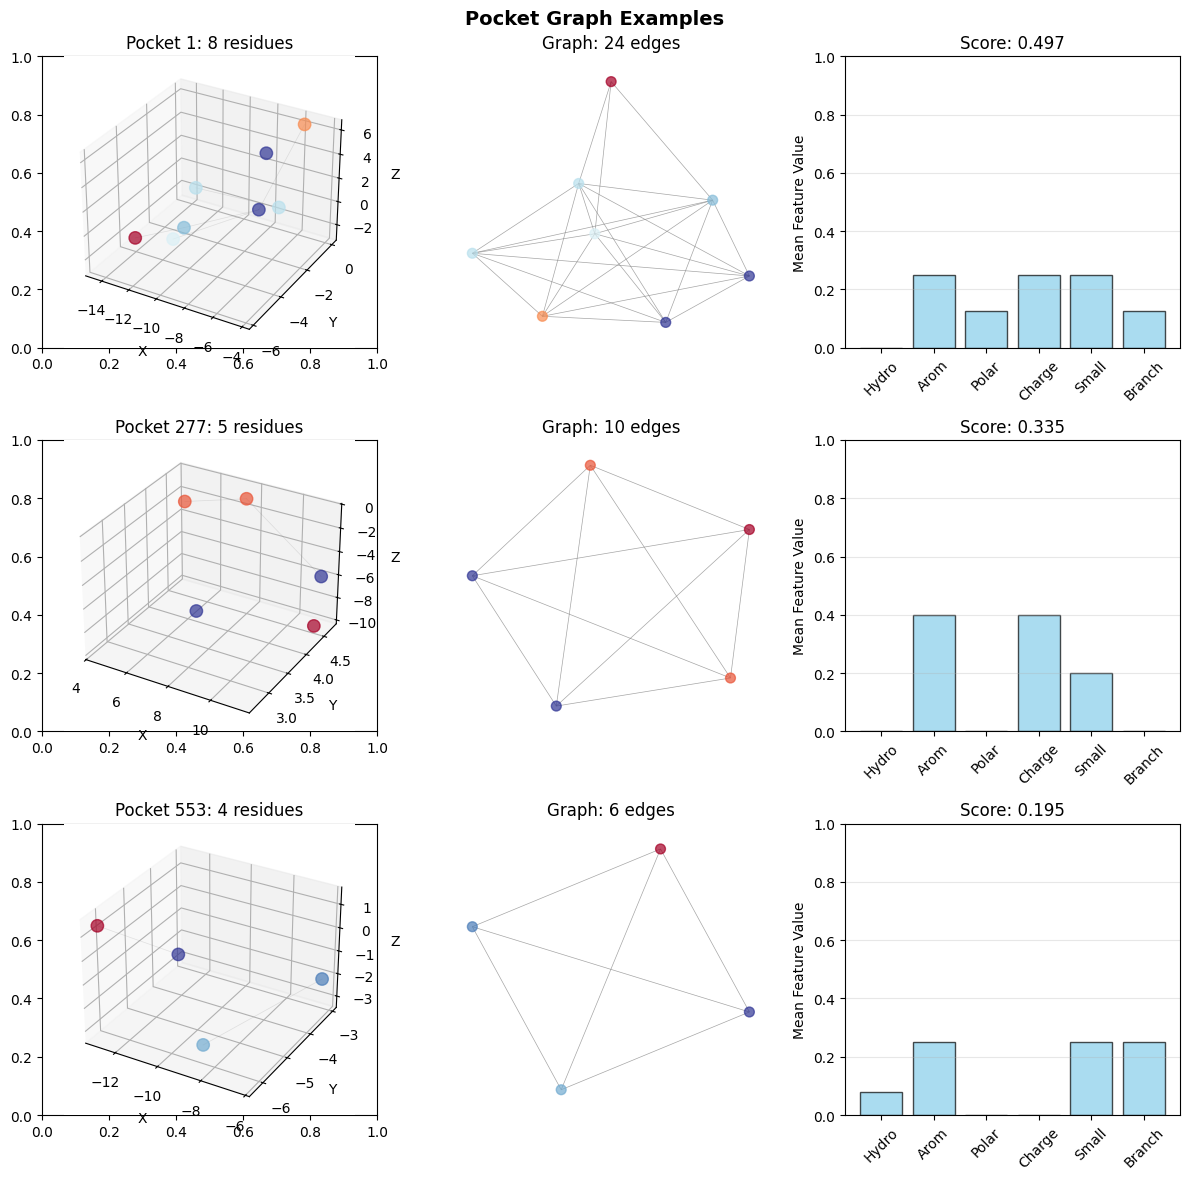

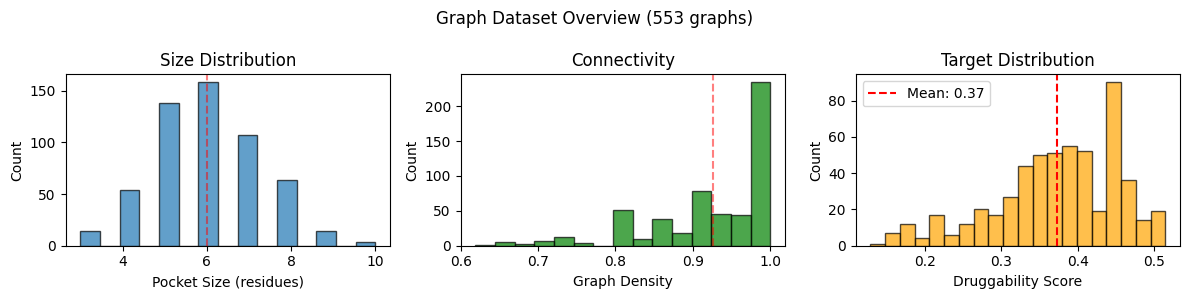

In [ ]:
def visualize_pocket_graphs(graphs, pocket_data, n_samples=3):
    # Select a few representative graphs
    indices = [0, len(graphs) // 2, len(graphs) - 1][: min(n_samples, len(graphs))]

    fig, axes = plt.subplots(n_samples, 3, figsize=(12, 4 * n_samples))
    if n_samples == 1:
        axes = axes.reshape(1, -1)

    for row, idx in enumerate(indices):
        graph = graphs[idx]
        pocket = pocket_data[idx]

        # 3D structure
        ax1 = fig.add_subplot(n_samples, 3, row * 3 + 1, projection="3d")
        pos = graph.pos.numpy()

        # Color by residue hydrophobicity
        colors = [
            HYDROPHOBICITY.get(r["residue_name"], 0.0) for r in pocket["residues"]
        ]

        ax1.scatter(
            pos[:, 0], pos[:, 1], pos[:, 2], c=colors, cmap="RdYlBu_r", s=80, alpha=0.7
        )

        edge_index = graph.edge_index.numpy()
        for i in range(0, edge_index.shape[1], 10):
            p1, p2 = pos[edge_index[0, i]], pos[edge_index[1, i]]
            ax1.plot(
                [p1[0], p2[0]],
                [p1[1], p2[1]],
                [p1[2], p2[2]],
                "gray",
                alpha=0.2,
                linewidth=0.5,
            )

        ax1.set_title(f"Pocket {idx + 1}: {pocket['size']} residues")
        ax1.set_xlabel("X")
        ax1.set_ylabel("Y")
        ax1.set_zlabel("Z")

        G = nx.Graph()
        edges = [
            (edge_index[0, i], edge_index[1, i])
            for i in range(edge_index.shape[1])
            if edge_index[0, i] < edge_index[1, i]
        ]
        G.add_edges_from(edges)

        ax2 = axes[row, 1]
        layout = nx.spring_layout(G, seed=16)
        nx.draw(
            G,
            layout,
            ax=ax2,
            node_size=50,
            node_color=colors,
            cmap="RdYlBu_r",
            edge_color="gray",
            width=0.5,
            alpha=0.7,
        )
        ax2.set_title(f"Graph: {len(edges)} edges")
        ax2.axis("off")

        ax3 = axes[row, 2]
        features_subset = graph.x.numpy()[:, 20:26]  # Select key features

        feature_means = features_subset.mean(axis=0)
        feature_labels = ["Hydro", "Arom", "Polar", "Charge", "Small", "Branch"]

        ax3.bar(
            range(len(feature_means)),
            feature_means,
            color="skyblue",
            edgecolor="black",
            alpha=0.7,
        )
        ax3.set_xticks(range(len(feature_labels)))
        ax3.set_xticklabels(feature_labels, rotation=45)
        ax3.set_title(f"Score: {graph.y.item():.3f}")
        ax3.set_ylabel("Mean Feature Value")
        ax3.set_ylim([0, 1])
        ax3.grid(axis="y", alpha=0.3)

    plt.suptitle("Pocket Graph Examples", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()


def plot_graph_stats(graphs):
    fig, axes = plt.subplots(1, 3, figsize=(12, 3))

    # Pocket sizes
    sizes = [g.num_nodes for g in graphs]
    axes[0].hist(sizes, bins=15, alpha=0.7, edgecolor="black")
    axes[0].set_xlabel("Pocket Size (residues)")
    axes[0].set_ylabel("Count")
    axes[0].set_title("Size Distribution")
    axes[0].axvline(np.mean(sizes), color="red", linestyle="--", alpha=0.5)

    # Edge density
    densities = []
    for g in graphs:
        n = g.num_nodes
        e = g.edge_index.shape[1] / 2
        density = 2 * e / (n * (n - 1)) if n > 1 else 0
        densities.append(density)

    axes[1].hist(densities, bins=15, alpha=0.7, edgecolor="black", color="green")
    axes[1].set_xlabel("Graph Density")
    axes[1].set_ylabel("Count")
    axes[1].set_title("Connectivity")
    axes[1].axvline(np.mean(densities), color="red", linestyle="--", alpha=0.5)

    # Target scores
    scores = [g.y.item() for g in graphs]
    axes[2].hist(scores, bins=20, alpha=0.7, edgecolor="black", color="orange")
    axes[2].set_xlabel("Druggability Score")
    axes[2].set_ylabel("Count")
    axes[2].set_title("Target Distribution")
    axes[2].axvline(
        np.mean(scores),
        color="red",
        linestyle="--",
        label=f"Mean: {np.mean(scores):.2f}",
    )
    axes[2].legend()

    plt.suptitle(f"Graph Dataset Overview ({len(graphs)} graphs)", fontsize=12)
    plt.tight_layout()
    plt.show()


visualize_pocket_graphs(
    enhanced_graphs, pocket_data, n_samples=min(3, len(enhanced_graphs))
)
plot_graph_stats(enhanced_graphs)

## **Part 4: Pocket Druggability Prediction with Attentive GNN**

This section trains an **Attentive PocketGNN** to predict the **druggability** of pockets represented as graphs.
Each graph (from Part 3) encodes residue-level geometry, chemistry, and global pocket properties.
The model learns to classify pockets as **druggable (1)** or **non-druggable (0)** and rank them by probability.

**Overview**

* Defines a **focal-loss objective** to handle class imbalance between persistent and cryptic pockets.
* Uses a **multi-head Graph Attention Network (GAT)** with GraphNorm and residuals to capture intra-pocket interactions.
* Incorporates **global pocket descriptors** via a secondary MLP encoder and fuses them with pooled node embeddings.
* Includes a full **training framework** (Trainer) for loss tracking, early stopping, and evaluation.


**Outputs**

* Trained **AttentivePocketGNN** with optimal threshold.
* Validation/test performance summary (AUROC, AUPRC, F1).
* **Ranked pockets** with calibrated druggability probabilities.
* **Plots:**

  * Training loss & validation metrics.
  * Probability distribution, size vs score, and persistent vs cryptic comparison.
  * Table of top 20 predicted druggable pockets with size, depth, volume, hydrophobicity, and status.




In [ ]:
class FocalLossWithLogits(nn.Module):
    # Binary focal loss on logits.
    # alpha: weight for positive class (higher when positives are rare)
    # gamma: focusing parameter
    def __init__(self, alpha=0.85, gamma=2.0):
        super().__init__()
        self.alpha = float(alpha)
        self.gamma = float(gamma)

    def forward(self, logits, targets):
        # logits [B], targets [B] in {0,1}
        bce = F.binary_cross_entropy_with_logits(logits, targets, reduction="none")
        p = torch.sigmoid(logits).detach()
        alpha_t = self.alpha * targets + (1.0 - self.alpha) * (1.0 - targets)
        p_t = p * targets + (1.0 - p) * (1.0 - targets)
        mod = (1.0 - p_t).pow(self.gamma)
        loss = alpha_t * mod * bce
        return loss.mean()

**Model Architecture**

* **Node encoder:** linear → ReLU → dropout.
* **Attention stack:** three GATConv + GraphNorm + residual layers.
* **Global encoder:** MLP (64 → 32 dims).
* **Fusion head:** concatenates mean, max, sum graph pools + global embedding → MLP → 1 logit.
* **Output:** sigmoid(logit) ≈ druggability probability.

gnn_architecture.svg

In [ ]:
class AttentivePocketGNN(nn.Module):
    def __init__(
        self, node_dim, edge_dim, global_dim, hidden_dim=128, heads=4, dropout=0.3
    ):
        super().__init__()

        # Node encoder
        self.node_encoder = Sequential(
            Linear(node_dim, hidden_dim), nn.ReLU(), Dropout(dropout)
        )

        # GAT stack + GraphNorm
        self.gat1 = GATConv(
            hidden_dim,
            hidden_dim // heads,
            heads=heads,
            dropout=dropout,
            edge_dim=edge_dim,
        )
        self.gn1 = GraphNorm(hidden_dim)

        self.gat2 = GATConv(
            hidden_dim,
            hidden_dim // heads,
            heads=heads,
            dropout=dropout,
            edge_dim=edge_dim,
        )
        self.gn2 = GraphNorm(hidden_dim)

        self.gat3 = GATConv(
            hidden_dim, hidden_dim, heads=1, dropout=dropout, edge_dim=edge_dim
        )
        self.gn3 = GraphNorm(hidden_dim)

        # Global encoder
        self.global_encoder = Sequential(
            Linear(global_dim, 64),
            LayerNorm(64),
            nn.ReLU(),
            Dropout(dropout),
            Linear(64, 32),
        )

        # Fusion head
        self.fusion = Sequential(
            Linear(hidden_dim * 3 + 32, 256),
            LayerNorm(256),
            nn.ReLU(),
            Dropout(dropout),
            Linear(256, 128),
            LayerNorm(128),
            nn.ReLU(),
            Dropout(dropout),
            Linear(128, 64),
            LayerNorm(64),
            nn.ReLU(),
            Linear(64, 1),
        )

        self.dropout = Dropout(dropout)

    def forward(self, batch):
        x, edge_index = batch.x, batch.edge_index
        edge_attr = getattr(batch, "edge_attr", None)

        # Node path
        x = self.node_encoder(x)

        x1 = self.gat1(x, edge_index, edge_attr)
        x1 = F.relu(self.gn1(x1, batch=batch.batch))
        x1 = self.dropout(x1)

        x2 = self.gat2(x1, edge_index, edge_attr)
        x2 = F.relu(self.gn2(x2, batch=batch.batch))
        x2 = self.dropout(x2)
        x2 = x2 + x1  # residual

        x3 = self.gat3(x2, edge_index, edge_attr)
        x3 = F.relu(self.gn3(x3, batch=batch.batch))
        x3 = self.dropout(x3)

        # Graph-level pooling
        x_mean = global_mean_pool(x3, batch.batch)
        x_max = global_max_pool(x3, batch.batch)
        x_sum = global_add_pool(x3, batch.batch)

        # Global features
        if hasattr(batch, "u"):
            u = batch.u
            if u.dim() == 1:
                u = u.view(batch.num_graphs, -1)
            elif u.dim() == 2 and u.size(0) != batch.num_graphs:
                u = u.view(batch.num_graphs, -1)
        else:
            u = torch.stack([d.u for d in batch.to_data_list()])
        u = u.to(x_mean.device).float()

        u_encoded = self.global_encoder(u)

        # Fusion -> logits
        combined = torch.cat([x_mean, x_max, x_sum, u_encoded], dim=1)
        logits = self.fusion(combined).squeeze(1)
        return logits

    def get_attention_weights(self, batch):
        x, edge_index = batch.x, batch.edge_index
        edge_attr = getattr(batch, "edge_attr", None)
        x = self.node_encoder(x)
        _, (edge_index_out, attn) = self.gat1(
            x, edge_index, edge_attr, return_attention_weights=True
        )
        return edge_index_out, attn

Utility functions for evaluating binary classification model performance and selecting an optimal classification threshold.

*   `_conf_counts(y_true, y_prob, thr)`: Calculates the counts of true positives (TP), true negatives (TN), false positives (FP), and false negatives (FN) based on true labels (`y_true`), predicted probabilities (`y_prob`), and a given classification threshold (`thr`).
*   `_safe_metrics(tp, tn, fp, fn, eps)`: Computes various classification metrics (Precision, Recall, F1-score, True Positive Rate/Recall, False Positive Rate, and Youden's J statistic) from the confusion matrix counts (TP, TN, FP, FN). It includes a small epsilon (`eps`) to prevent division by zero.
*   `choose_threshold(y_true, y_prob, min_precision, strategy, guard)`: Selects an optimal classification threshold from a range of potential values (derived from unique probabilities). It prioritizes thresholds that maximize the F1-score while meeting a minimum precision requirement (`min_precision`). If no such threshold is found, it falls back to selecting the threshold that maximizes Youden's J statistic (TPR - FPR). The `guard` parameter helps define the lower and upper bounds of potential thresholds to consider.

In [ ]:
def _conf_counts(y_true, y_prob, thr):
    y_pred = (y_prob >= thr).astype(int)
    tp = np.sum((y_true == 1) & (y_pred == 1))
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    return tp, tn, fp, fn


def _safe_metrics(tp, tn, fp, fn, eps=1e-12):
    prec = tp / max(tp + fp, eps)
    rec = tp / max(tp + fn, eps)
    f1 = 2 * prec * rec / max(prec + rec, eps)
    tpr = rec
    fpr = fp / max(fp + tn, eps)
    youden = tpr - fpr
    return prec, rec, f1, youden


def choose_threshold(
    y_true, y_prob, min_precision=0.50, strategy="f1_then_youden", guard=(0.05, 0.95)
):

    # Sweep thresholds over unique probs and return a robust threshold.
    # First try: argmax F1 with precision >= min_precision.
    # Fallback: argmax Youden's J.

    probs = np.asarray(y_prob)
    y = np.asarray(y_true).astype(int)

    # candidate thresholds: unique probs + small guards
    ths = np.unique(probs)
    ths = np.clip(ths, guard[0], guard[1])
    ths = np.unique(np.r_[guard[0], ths, guard[1]])

    best = {"thr": 0.5, "f1": -1, "prec": 0.0, "rec": 0.0, "youden": -1}
    # constrained F1 search
    for t in ths:
        tp, tn, fp, fn = _conf_counts(y, probs, t)
        prec, rec, f1, youden = _safe_metrics(tp, tn, fp, fn)
        if prec >= min_precision and f1 > best["f1"]:
            best = {
                "thr": float(t),
                "f1": f1,
                "prec": prec,
                "rec": rec,
                "youden": youden,
            }

    if best["f1"] >= 0:
        return best["thr"]

    # fallback: Youden's J (max TPR-FPR)
    best_yj = {"thr": 0.5, "youden": -1}
    for t in ths:
        tp, tn, fp, fn = _conf_counts(y, probs, t)
        _, _, _, youden = _safe_metrics(tp, tn, fp, fn)
        if youden > best_yj["youden"]:
            best_yj = {"thr": float(t), "youden": youden}
    return best_yj["thr"]

This code defines the `Trainer` class for training for `AttentivePocketGNN`.

### Specifics

*   **`__init__`**: Initializes the trainer with the model, device (CPU/GPU), loss function, optimizer (AdamW), and a learning rate scheduler (`ReduceLROnPlateau`). It also sets up attributes for tracking the best model state, training history (loss, validation AUROC, and AUPRC), and the best validation threshold.
*   **`_targets`**: A static method to extract and reshape the target labels from a batch of data.
*   **`_epoch`**: Performs a single training or evaluation epoch.
    *   Sets the model to train or evaluation mode.
    *   Iterates through the data loader, calculates the loss, and performs backpropagation and optimization steps during training.
    *   Collects predicted probabilities and true targets for metric calculation.
    *   Computes AUROC and AUPRC for the epoch.
    *   Returns the average loss and calculated metrics.
*   **`fit`**: Manages the training loop over multiple epochs.
    *   Iterates through the specified number of epochs.
    *   Calls `_epoch` for both training and validation.
    *   Selects the best classification threshold based on validation performance using the `choose_threshold` function.
    *   Tracks training history and saves the model state if validation performance improves (based on AUPRC).
    *   Implements early stopping if validation performance does not improve for a set number of epochs.
    *   Loads the best model state at the end of training.
    *   Returns the training history.
*   **`evaluate`**: Evaluates the model on a given data loader using the best validation threshold.
    *   Calculates AUROC, AUPRC, accuracy, and F1 score.
    *   Computes and returns the confusion matrix counts (TP, TN, FP, FN).
*   **`evaluate_logits`**: Returns the raw logits and targets for a given loader, used for calibration.
*   **`calibrate_on_validation`**: Performs Platt calibration (using Logistic Regression) on the validation set to obtain calibrated probabilities and a calibrated best threshold.

In [ ]:
class Trainer:
    def __init__(self, model, device, loss_fn, learning_rate=1e-3, weight_decay=1e-4):
        self.model = model.to(device)
        self.device = device
        self.optimizer = torch.optim.AdamW(
            model.parameters(), lr=learning_rate, weight_decay=weight_decay
        )
        self.scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            self.optimizer, mode="max", factor=0.5, patience=5
        )
        self.loss_fn = loss_fn
        self.best_metric = -float("inf")
        self.best_state = None
        self.history = {"train_loss": [], "val_auroc": [], "val_auprc": []}
        self.val_best_threshold = 0.5

    @staticmethod
    def _targets(batch):  # [B]
        return batch.y.view(-1).float()

    def _epoch(self, loader, train=True):
        if train:
            self.model.train()
        else:
            self.model.eval()

        total_loss, total = 0.0, 0
        all_probs, all_tgts = [], []

        for batch in loader:
            batch = batch.to(self.device)
            logits = self.model(batch)
            y = self._targets(batch)
            loss = self.loss_fn(logits, y)

            if train:
                self.optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
                self.optimizer.step()

            total_loss += loss.item() * batch.num_graphs
            total += batch.num_graphs

            with torch.no_grad():
                probs = torch.sigmoid(logits)
                all_probs.append(probs.detach().cpu())
                all_tgts.append(y.detach().cpu())

        all_probs = torch.cat(all_probs).numpy()
        all_tgts = torch.cat(all_tgts).numpy()

        try:
            auroc = roc_auc_score(all_tgts, all_probs)
        except ValueError:
            auroc = np.nan
        try:
            auprc = average_precision_score(all_tgts, all_probs)
        except ValueError:
            auprc = np.nan

        return (total_loss / max(total, 1)), auroc, auprc, all_probs, all_tgts

    def fit(self, train_loader, val_loader, epochs=80, early_stopping_patience=12):
        no_improve = 0
        for ep in range(1, epochs + 1):
            train_loss, _, _, _, _ = self._epoch(train_loader, train=True)
            _, val_auroc, val_auprc, vp, vt = self._epoch(val_loader, train=False)

            # best threshold by F1 (on raw validation probabilities)
            precision, recall, ths = precision_recall_curve(vt, vp)
            f1s = 2 * precision * recall / (precision + recall + 1e-8)
            bidx = int(np.nanargmax(f1s))
            best_th = choose_threshold(vt, vp, min_precision=0.50)
            self.val_best_threshold = float(best_th)

            self.history["train_loss"].append(train_loss)
            self.history["val_auroc"].append(val_auroc)
            self.history["val_auprc"].append(val_auprc)

            metric = val_auprc if not np.isnan(val_auprc) else -np.inf
            if metric > self.best_metric + 1e-5:
                self.best_metric = metric
                self.best_state = {
                    k: v.detach().cpu().clone()
                    for k, v in self.model.state_dict().items()
                }
                no_improve = 0
            else:
                no_improve += 1

            self.scheduler.step(metric)

            if ep % 5 == 0 or ep == 1:
                print(
                    f"Epoch {ep:03d} | train_loss={train_loss:.4f} | val_AUROC={val_auroc:.3f} | "
                    f"val_AUPRC={val_auprc:.3f} | best_th={self.val_best_threshold:.3f}"
                )

            if no_improve >= early_stopping_patience:
                print(f"Early stopping at epoch {ep}")
                break

        if self.best_state is not None:
            self.model.load_state_dict(self.best_state)
        return self.history

    def evaluate(self, loader, threshold=None):
        self.model.eval()
        _, auroc, auprc, probs, tgts = self._epoch(loader, train=False)
        if threshold is None:
            threshold = self.val_best_threshold
        preds = (probs >= threshold).astype(int)
        acc = (preds == tgts).mean()
        try:
            tn, fp, fn, tp = confusion_matrix(tgts, preds, labels=[0, 1]).ravel()
        except ValueError:
            tn = np.sum((tgts == 0) & (preds == 0))
            fp = np.sum((tgts == 0) & (preds == 1))
            fn = np.sum((tgts == 1) & (preds == 0))
            tp = np.sum((tgts == 1) & (preds == 1))
        f1 = f1_score(tgts, preds, zero_division=0)
        return {
            "AUROC": auroc,
            "AUPRC": auprc,
            "ACC": acc,
            "F1": f1,
            "threshold": threshold,
            "TN": int(tn),
            "FP": int(fp),
            "FN": int(fn),
            "TP": int(tp),
            "probs": probs,
            "targets": tgts,
        }

    # Raw logits/targets for calibration
    def evaluate_logits(self, loader):
        self.model.eval()
        all_logits, all_targets = [], []
        with torch.no_grad():
            for batch in loader:
                batch = batch.to(self.device)
                logits = self.model(batch)
                y = batch.y.view(-1).float()
                all_logits.append(logits.detach().cpu())
                all_targets.append(y.detach().cpu())
        return torch.cat(all_logits).numpy(), torch.cat(all_targets).numpy()

    # Platt calibration on validation
    def calibrate_on_validation(self, val_loader):
        val_logits, val_tgts = self.evaluate_logits(val_loader)
        lr = LogisticRegression(max_iter=1000, class_weight="balanced")
        lr.fit(val_logits.reshape(-1, 1), val_tgts)
        val_probs_cal = lr.predict_proba(val_logits.reshape(-1, 1))[:, 1]

        best_th = choose_threshold(
            val_tgts, val_probs_cal, min_precision=0.50
        )  # same constraint
        return lr, float(best_th), (val_probs_cal, val_tgts)


# Group-wise split
def infer_groups(enhanced_graphs, pocket_data=None):
    groups = []
    for i, g in enumerate(enhanced_graphs):
        pid = getattr(g, "protein_id", None)
        if pid is None:
            pid = getattr(g, "target_id", None)
        if pid is None and pocket_data is not None:
            conf_id = pocket_data[i]["conf_id"]
            pid = int(conf_id // 10)  # group conformers by coarse id
        if pid is None:
            pid = 0
        groups.append(pid)
    return np.array(groups)


def build_group_splits(enhanced_graphs, y_values, pocket_data=None, seed=16):
    indices = np.arange(len(enhanced_graphs))
    groups = infer_groups(enhanced_graphs, pocket_data)
    gkf_outer = GroupKFold(n_splits=5)
    outer_splits = list(gkf_outer.split(indices, y_values, groups))
    trainval_idx, test_idx = outer_splits[0]
    gkf_inner = GroupKFold(n_splits=5)
    inner_splits = list(
        gkf_inner.split(trainval_idx, y_values[trainval_idx], groups[trainval_idx])
    )
    tr, va = inner_splits[0]
    train_idx = trainval_idx[tr]
    val_idx = trainval_idx[va]
    return train_idx, val_idx, test_idx, groups

In [ ]:
# Model input dims
node_dim = enhanced_graphs[0].x.shape[1]
edge_dim = (
    enhanced_graphs[0].edge_attr.shape[1]
    if enhanced_graphs[0].edge_attr.shape[0] > 0
    else 0
)
global_dim = enhanced_graphs[0].u.shape[0]
print(
    f"Model input dimensions: nodes={node_dim}, edges={edge_dim}, global={global_dim}"
)

# Sanitization
for g in enhanced_graphs:
    y = float(g.y.squeeze().item())
    g.y = torch.tensor([1.0 if y >= 0.5 else 0.0], dtype=torch.float32)

# Group wise splits
y_values = np.array([g.y.item() for g in enhanced_graphs], dtype=float)
train_idx, val_idx, test_idx, groups = build_group_splits(
    enhanced_graphs, y_values, pocket_data
)

train_set = [enhanced_graphs[i] for i in train_idx]
val_set = [enhanced_graphs[i] for i in val_idx]
test_set = [enhanced_graphs[i] for i in test_idx]

# Weighted sampler
train_y = np.array([g.y.item() for g in train_set], dtype=float)
pos_idx = train_y == 1.0
neg_idx = ~pos_idx
w_pos = 0.5 / max(1, pos_idx.sum())
w_neg = 0.5 / max(1, neg_idx.sum())
sample_weights = np.where(pos_idx, w_pos, w_neg).astype(np.float32)
sampler = torch.utils.data.WeightedRandomSampler(
    sample_weights, num_samples=len(train_set), replacement=True
)

train_loader = DataLoader(train_set, batch_size=32, sampler=sampler, drop_last=False)
val_loader = DataLoader(val_set, batch_size=64, shuffle=False)
test_loader = DataLoader(test_set, batch_size=64, shuffle=False)

Model input dimensions: nodes=30, edges=4, global=11


**Training Setup**

* **Loss:** Focal Loss with α = 0.85, γ = 2.0 (focuses learning on minority positives).
* **Optimizer:** AdamW + ReduceLROnPlateau scheduler.
* **Sampling:** WeightedRandomSampler balances positive/negative graphs.
* **Splitting:** Group K-Fold (5×) ensures conformers of the same protein stay in one split.
* **Metrics:** AUROC, AUPRC, accuracy, F1; validation threshold chosen by F1 + Youden’s J.
* **Calibration:** Platt (Logistic Regression) for probabilistic consistency.

In [ ]:
# Model + loss + trainer
model = AttentivePocketGNN(
    node_dim=node_dim,
    edge_dim=edge_dim,
    global_dim=global_dim,
    hidden_dim=128,
    heads=4,
    dropout=0.3,
)
loss_fn = FocalLossWithLogits(alpha=0.85, gamma=2.0)
trainer = Trainer(model, device, loss_fn, learning_rate=1e-3, weight_decay=1e-4)

# Train
history = trainer.fit(train_loader, val_loader, epochs=80, early_stopping_patience=12)

# Evaluation: validation-driven threshold
val_metrics = trainer.evaluate(val_loader)
test_metrics = trainer.evaluate(test_loader)
print(
    "\nValidation:",
    {
        k: round(v, 3) if isinstance(v, float) else v
        for k, v in val_metrics.items()
        if k not in ("probs", "targets")
    },
)
print(
    "Test:",
    {
        k: round(v, 3) if isinstance(v, float) else v
        for k, v in test_metrics.items()
        if k not in ("probs", "targets")
    },
)

Epoch 001 | train_loss=0.0600 | val_AUROC=0.936 | val_AUPRC=0.467 | best_th=0.676
Epoch 005 | train_loss=0.0556 | val_AUROC=0.951 | val_AUPRC=0.542 | best_th=0.703
Epoch 010 | train_loss=0.0131 | val_AUROC=0.977 | val_AUPRC=0.736 | best_th=0.857
Epoch 015 | train_loss=0.0054 | val_AUROC=0.971 | val_AUPRC=0.528 | best_th=0.163
Early stopping at epoch 18

Validation: {'AUROC': np.float64(0.991), 'AUPRC': np.float64(0.893), 'ACC': np.float64(0.044), 'F1': 0.085, 'threshold': 0.106, 'TN': 0, 'FP': 86, 'FN': 0, 'TP': 4}
Test: {'AUROC': np.float64(0.983), 'AUPRC': np.float64(0.417), 'ACC': np.float64(0.017), 'F1': 0.033, 'threshold': 0.106, 'TN': 0, 'FP': 118, 'FN': 0, 'TP': 2}


In [ ]:
# Plots training loss + validation AUROC/AUPRC
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history["train_loss"], label="Train Loss", alpha=0.9)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Training Loss")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(history["val_auroc"], label="Val AUROC", alpha=0.9)
axes[1].plot(history["val_auprc"], label="Val AUPRC", alpha=0.9)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Metric")
axes[1].set_title("Validation Metrics")
axes[1].grid(True, alpha=0.3)
axes[1].legend()
plt.tight_layout()
plt.show()

# CALIBRATION on validation, then evaluate on test with calibrated probs
platt, best_th_cal, (val_probs_cal, val_tgts) = trainer.calibrate_on_validation(
    val_loader
)
print(f"Calibrated best threshold (val): {best_th_cal:.3f}")

test_logits, test_tgts = trainer.evaluate_logits(test_loader)
test_probs_cal = platt.predict_proba(test_logits.reshape(-1, 1))[:, 1]

test_auroc = (
    roc_auc_score(test_tgts, test_probs_cal)
    if len(np.unique(test_tgts)) > 1
    else np.nan
)
test_auprc = average_precision_score(test_tgts, test_probs_cal)
test_preds = (test_probs_cal >= best_th_cal).astype(int)
test_acc = (test_preds == test_tgts).mean()
test_f1 = f1_score(test_tgts, test_preds, zero_division=0)
tn, fp, fn, tp = (
    confusion_matrix(test_tgts, test_preds, labels=[0, 1]).ravel()
    if len(np.unique(test_tgts)) > 1
    else (np.nan, np.nan, np.nan, np.nan)
)

print(
    "TEST (calibrated):",
    {
        "AUROC": round(test_auroc, 3) if not np.isnan(test_auroc) else test_auroc,
        "AUPRC": round(test_auprc, 3),
        "ACC": round(test_acc, 3),
        "F1": round(test_f1, 3),
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "thr": round(best_th_cal, 3),
    },
)


TOP DRUGGABLE POCKETS
 1. Score: 0.781 | Size:  9 | Conf:  46 | Status: Cryptic   | Hydrophobicity: -0.16
 2. Score: 0.759 | Size:  8 | Conf:   0 | Status: Persistent | Hydrophobicity: -0.10
 3. Score: 0.748 | Size:  8 | Conf: 173 | Status: Persistent | Hydrophobicity: -0.10
 4. Score: 0.744 | Size:  9 | Conf:  42 | Status: Cryptic   | Hydrophobicity: -0.16
 5. Score: 0.735 | Size:  9 | Conf:  51 | Status: Persistent | Hydrophobicity: -0.33
 6. Score: 0.729 | Size:  8 | Conf:  33 | Status: Persistent | Hydrophobicity: -0.29
 7. Score: 0.723 | Size:  9 | Conf:  20 | Status: Cryptic   | Hydrophobicity: -0.16
 8. Score: 0.723 | Size:  8 | Conf:  17 | Status: Persistent | Hydrophobicity: -0.10
 9. Score: 0.718 | Size:  8 | Conf:  38 | Status: Persistent | Hydrophobicity: -0.10
10. Score: 0.712 | Size:  8 | Conf:   1 | Status: Persistent | Hydrophobicity: -0.10


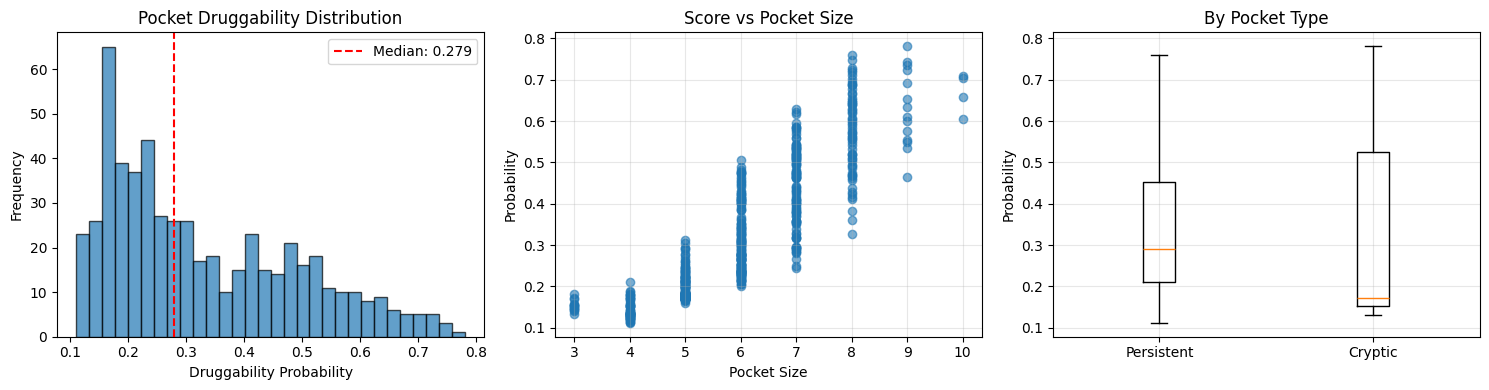


Top 20 Pockets Summary:
 rank  conf_id  size    score  hydrophobicity  is_cryptic  volume     depth
    1       46     9 0.781352       -0.162222        True   270.0  8.391583
    2        0     8 0.758933       -0.095000       False   240.0  9.987114
    3      173     8 0.747927       -0.095000       False   240.0  6.948598
    4       42     9 0.744036       -0.162222        True   270.0 10.075573
    5       51     9 0.734827       -0.331111       False   270.0  9.597192
    6       33     8 0.728652       -0.285000       False   240.0  8.902904
    7       20     9 0.723144       -0.162222        True   270.0  7.903704
    8       17     8 0.723014       -0.095000       False   240.0  7.164904
    9       38     8 0.717639       -0.095000       False   240.0  9.435083
   10        1     8 0.711901       -0.095000       False   240.0 10.127522
   11       39    10 0.710210       -0.368000        True   300.0  6.699066
   12      125    10 0.704731       -0.258000        True   300

In [ ]:
# Score all pockets using calibrated probs
model.eval()
all_predictions = []
with torch.no_grad():
    for g in enhanced_graphs:
        batch = Batch.from_data_list([g]).to(device)
        logit = model(batch).item()
        # Uncalibrated:
        # prob  = torch.sigmoid(torch.tensor(logit)).item()
        # Calibrated (recommended for ranking):
        prob = platt.predict_proba(np.array(logit).reshape(-1, 1))[0, 1]
        all_predictions.append(float(prob))

for pocket, score in zip(pocket_data[: len(all_predictions)], all_predictions):
    pocket["gnn_score_advanced"] = score

ranked_pockets = sorted(
    pocket_data[: len(all_predictions)],
    key=lambda x: x["gnn_score_advanced"],
    reverse=True,
)

print("\nTOP DRUGGABLE POCKETS")
for i, pocket in enumerate(ranked_pockets[:10], 1):
    typ = "Cryptic" if pocket.get("is_cryptic", False) else "Persistent"
    print(
        f"{i:2d}. Score: {pocket['gnn_score_advanced']:.3f} | "
        f"Size: {pocket['size']:2d} | Conf: {pocket['conf_id']:3d} | "
        f"Status: {typ:9s} | Hydrophobicity: {pocket['hydrophobicity']:.2f}"
    )

# Analytics: distribution / size / type
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(all_predictions, bins=30, alpha=0.7, edgecolor="black")
axes[0].set_xlabel("Druggability Probability")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Pocket Druggability Distribution")
axes[0].axvline(
    np.median(all_predictions),
    color="red",
    linestyle="--",
    label=f"Median: {np.median(all_predictions):.3f}",
)
axes[0].legend()

sizes = [p["size"] for p in ranked_pockets]
scores = [p["gnn_score_advanced"] for p in ranked_pockets]
axes[1].scatter(sizes, scores, alpha=0.6)
axes[1].set_xlabel("Pocket Size")
axes[1].set_ylabel("Probability")
axes[1].set_title("Score vs Pocket Size")
axes[1].grid(True, alpha=0.3)

persist = [
    p["gnn_score_advanced"] for p in ranked_pockets if not p.get("is_cryptic", False)
]
cryptic = [
    p["gnn_score_advanced"] for p in ranked_pockets if p.get("is_cryptic", False)
]
axes[2].boxplot([persist, cryptic], labels=["Persistent", "Cryptic"])
axes[2].set_ylabel("Probability")
axes[2].set_title("By Pocket Type")
axes[2].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

top_pockets_df = pd.DataFrame(
    [
        {
            "rank": i,
            "conf_id": p["conf_id"],
            "size": p["size"],
            "score": p["gnn_score_advanced"],
            "hydrophobicity": p["hydrophobicity"],
            "is_cryptic": p.get("is_cryptic", False),
            "volume": p["volume"],
            "depth": p["depth"],
        }
        for i, p in enumerate(ranked_pockets[:20], 1)
    ]
)
print("\nTop 20 Pockets Summary:")
print(top_pockets_df.to_string(index=False))

##  **References & Implementation Inspirations**

This notebook is an experimentation that integrates **Graph Attention Network (GAT)** - based molecular representation learning and property prediction with **energy-based modeling principles** pf BioEMU. The architecture combines **node-level** and **global-level** embeddings via a dual-path fusion mechanism for structural and physicochemical inference.


- **BioEMU: Energy-Based Multimodal Model for Protein - Ligand Interaction Modeling**  
  Lin et al., *BioEMU: Energy-Based Multimodal Model of Protein, RNA, Ligand, and Antibody Complexes*, *bioRxiv* (2024).  
  [https://www.biorxiv.org/content/10.1101/2024.12.05.626885v1](https://www.biorxiv.org/content/10.1101/2024.12.05.626885v1.full.pdf)
- **Graph Attention Networks (GAT)**  
  Veličković et al., *Graph Attention Networks*, ICLR 2018.  
  [https://arxiv.org/abs/1710.10903](https://arxiv.org/abs/1710.10903)
- **GraphNorm: Normalization for Graph Neural Networks**  
  Cai et al., *GraphNorm: A Principled Approach to Normalize Graph Neural Networks*, NeurIPS 2021.  
  [https://arxiv.org/abs/2009.03294](https://arxiv.org/abs/2009.03294)
- **Layer Normalization & Dropout**  
  Ba et al., *Layer Normalization*, arXiv 2016.  
  [https://arxiv.org/abs/1607.06450](https://arxiv.org/abs/1607.06450)
- **Focal Loss for Class Imbalance**  
  Lin et al., *Focal Loss for Dense Object Detection*, ICCV 2017.  
  [https://arxiv.org/abs/1708.02002](https://arxiv.org/abs/1708.02002)
- **Calibration Metrics** - AUROC, AUPRC, and F1 follow sklearn's standard definitions  
  [https://scikit-learn.org/stable/modules/model_evaluation.html](https://scikit-learn.org/stable/modules/model_evaluation.html)
- **Optimization** - AdamW (Loshchilov & Hutter 2019) with weight decay regularization
- **PyTorch / PyTorch Geometric (PyG)** - for attention layers, batching, and graph processing  
  [https://pytorch.org](https://pytorch.org) · [https://pytorch-geometric.readthedocs.io](https://pytorch-geometric.readthedocs.io)



---

